In [32]:
import nibabel as nb 
import nilearn
import nilearn.datasets
import nilearn.plotting
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import datalad.api as dl
import os
import nilearn.plotting

os.environ["PATH"] = "/global/homes/m/mphagen/miniconda3/envs/fc_w_datalad/bin:" + os.environ["PATH"]


In [2]:
test_subs = np.loadtxt('../../../data/test_subjects.txt',dtype=str) 

In [7]:
# tsnr_nifti = nb.load('out_file_converted.nii.gz')

In [4]:
from nilearn.plotting import plot_epi, plot_roi, show
import nilearn.image

In [27]:
bids_dir = '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/time_series'

In [4]:
sub = test_subs[1]

In [12]:
nifti_file = glob(op.join(bids_dir, sub, 'MNINonLinear/Results/rfMRI_REST1_LR/*.nii.gz'))[0]

In [11]:
nifti_file

['/pscratch/sd/m/mphagen/hcp-functional-connectivity/930449/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_hp2000_clean.nii.gz']

In [14]:
nifti = nb.load(nifti_file)
nifti_data = nifti.get_fdata() 

In [15]:
tsnr_array = np.mean(nifti_data,axis=3) / np.std(nifti_data,axis=3) 
tsnr_array[np.isnan(tsnr_array)] = 0 

/tmp/ipykernel_193978/2422181189.py:1: RuntimeWarning: invalid value encountered in divide
  tsnr_array = np.mean(nifti_data,axis=3) / np.std(nifti_data,axis=3)


In [16]:
niimg = nb.Nifti1Image(tsnr_array, nifti.affine)

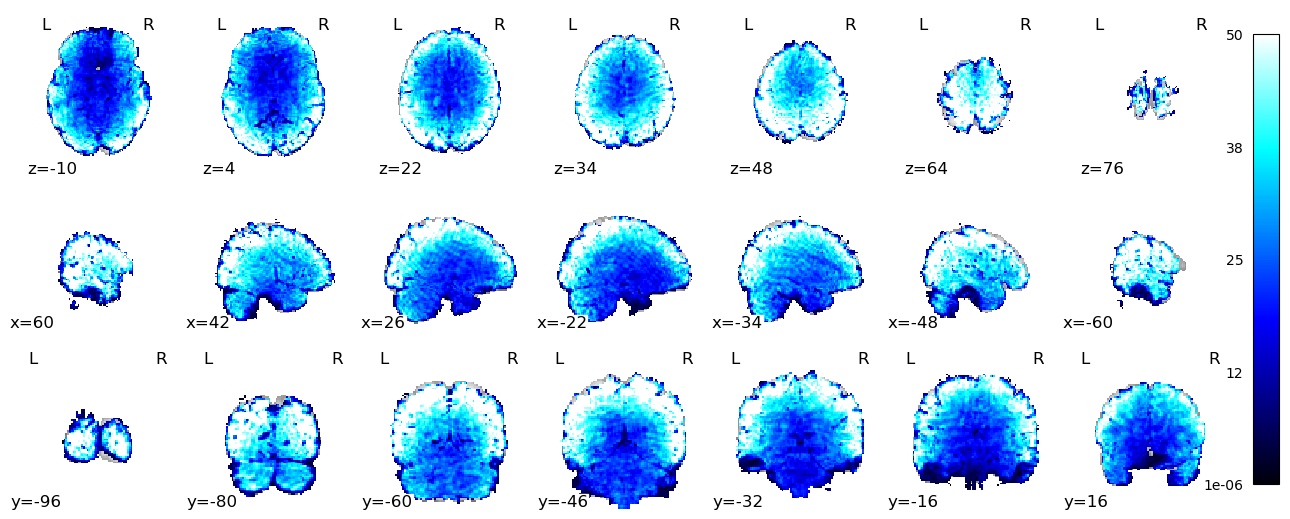

In [33]:
nilearn.plotting.plot_stat_map(niimg, display_mode='mosaic', cmap='black_blue', vmin=0, vmax=50)

In [34]:
from nilearn.plotting import view_img


/tmp/ipykernel_193978/2641878802.py:1: UserWarning: vmin cannot be chosen when cmap is symmetric
  view = view_img(niimg, threshold=3, vmin=0)
/global/homes/m/mphagen/miniconda3/envs/xcpd/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



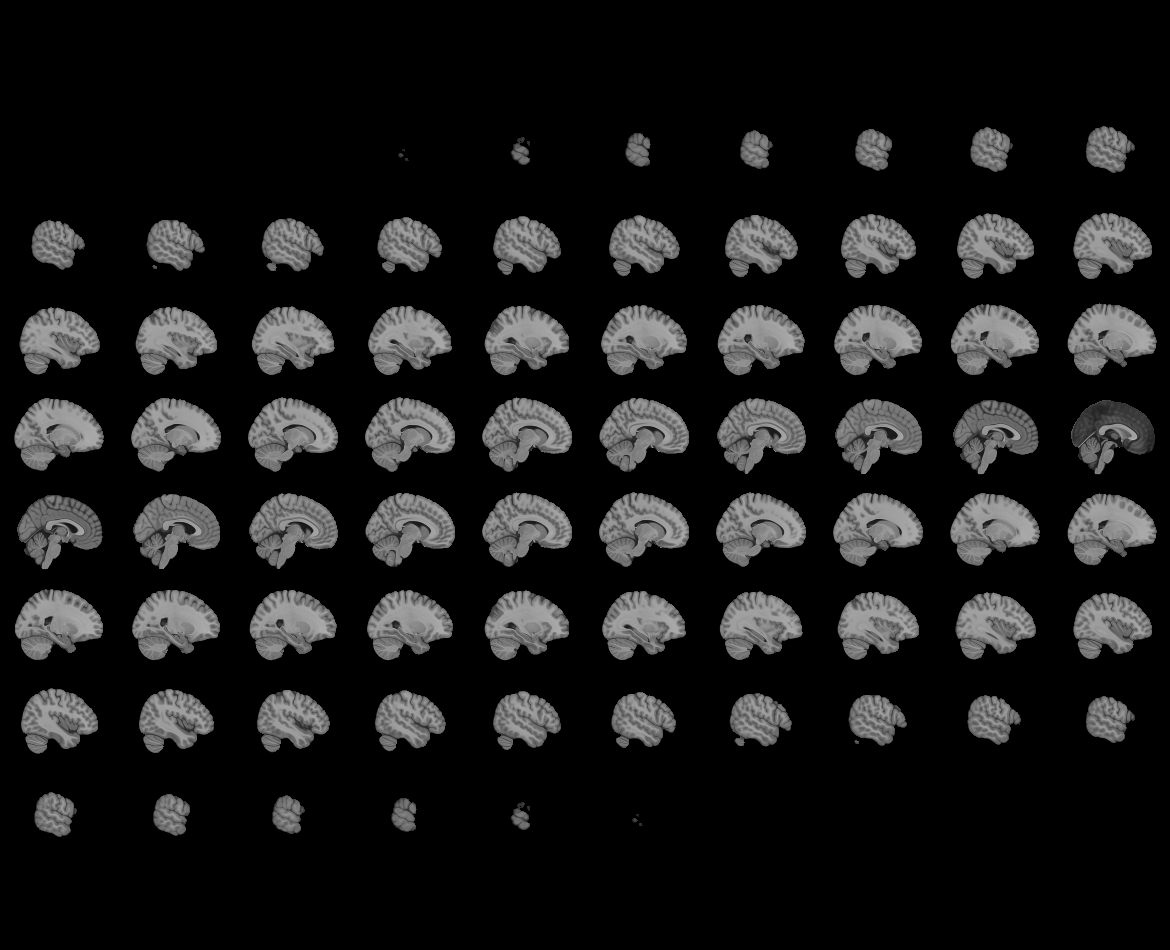
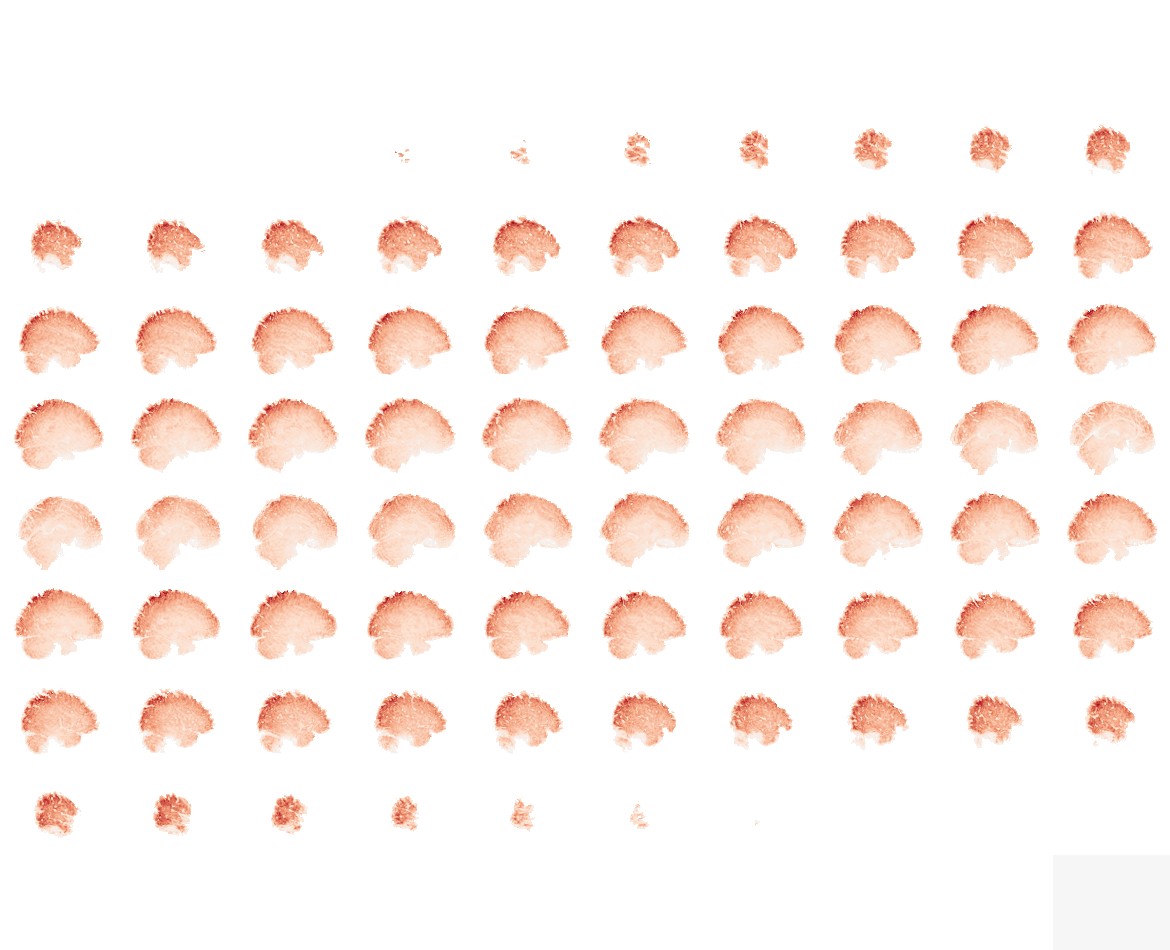

In [36]:
view = view_img(niimg, threshold=3, vmin=0)
view

In [20]:
schaefer = nilearn.datasets.fetch_atlas_schaefer_2018(n_rois=100) 
from nilearn.maskers import NiftiLabelsMasker
masker = NiftiLabelsMasker(labels_img=schaefer.maps)
parc_nifti =  masker.fit_transform(nifti) 

[fetch_atlas_schaefer_2018] Dataset found in /global/homes/m/mphagen/nilearn_data/schaefer_2018


In [24]:
parc_nifti.shape

(1200, 100)